# Enable the airline agent to use tools

## Defining Tools

In [1]:
from langchain_core.tools import tool

# Tiny in-memory "database"
DATABASE = {
    "flights": {
        # flight_key -> flight record
        "AY001_2026-02-22": {
            "flight_key": "AY001_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "09:30",
            "seats": 3,
            "price": 120,
        },
        "AY101_2026-02-22": {
            "flight_key": "AY101_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "16:10",
            "seats": 1,
            "price": 155,
        },
    },
    "bookings": {
        # booking_id → booking record
        "BKG-123": {
            "booking_id": "BKG-123",
            "flight_key": "AY001_2026-02-22",
            "passenger_name": "Jane Doe",
            "status": "confirmed",
        }
    },
}

# Tools
@tool
def get_booking (booking_id: str) -> str:
    """Retrieve a booking by ID."""
    booking_record = DATABASE ["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": f"Booking {booking_id} not found"}, ensure_ascii=False)
    
    flight_record = DATABASE["flights"].get(booking_record["flight_key"], {})
    return json.dumps(
        {"booking_id": booking_id, **booking_record, "flight": flight_record},
        ensure_ascii=False,
    )

In [2]:
@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search available flights."""
    matching_flights = [
        flight
        for flight in DATABASE["flights"].values()
            if flight["from"] == origin and
               flight["to"] == destination and
               flight["date"] == date and
               flight["seats"] > 0
    ]
    return json.dumps(
        sorted(matching_flights, key=lambda f: f["time"]),
        ensure_ascii=False,
    )

In [3]:
@tool
def cancel_booking (booking_id: str) -> str:
    """Cancel a booking."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": "Booking not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"])
    booking_record["status"] = "cancelled"

    if flight_record:
        flight_record["seats"] += 1
    
    refund_amount = flight_record["price"] if flight_record else 0
    
    return json.dumps({"success": True, "refund": refund_amount}, ensure_ascii=False)

In [4]:
TOOLS = [get_booking, search_flights, cancel_booking]

## Creating a Client

In [5]:
import getpass
import json
from langchain_openai import ChatOpenAI

OPENAI_API_KEY = getpass.getpass("Enter your API key:")

Enter your API key: ········


In [6]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENAI_API_KEY,
    model_name="gpt-5-nano",
)

## Defining an Agent

In [7]:
POLICIES: list[str] = [
    "Use tools when they are needed to answer accurately",
    "Never invent booking details, flight details, prices, or statuses",
    "If information is insufficient, ask clarifying questions."
    "Request confirmation before any booking cancellation. Ask explicitly and wait for user confirmation",
    "Retrieve the current booking before proposing changes",
]

In [8]:
SYSTEM_PROMPT = ("You are a virtual airline assistant." + f"\nPOLICIES: {chr(10).join(f"* {p}" for p in POLICIES)}").strip()

In [9]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENAI_API_KEY,
    model_name="gpt-5-nano",
).bind_tools(TOOLS)

In [10]:
## State

from typing import Annotated, TypedDict

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph.message import add_messages

class AgentStateRed(TypedDict):
    """Agent state with a reducer: messages will be appended, not overwritten."""
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
def ask(user_query: str, app):
    state = {"messages": [HumanMessage(content=user_query)]}
    out = app.invoke(state)
    return out["messages"][-1].content

In [12]:
## LLM nodes

def llm_with_tools_node(state: AgentStateRed) -> AgentStateRed:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": [resp]}

In [13]:
## Router decides whether to call tools
from typing import Literal

def route_after_llm(state: AgentStateRed) -> Literal["tools", "end"]:
    last_state = state["messages"][-1]
    has_tool_calls = getattr(last_state, "tool_calls", None)
    return "tools" if has_tool_calls else "end"

In [14]:
## Execution graph

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [15]:
graph = StateGraph(AgentStateRed)

graph.add_node("llm", llm_with_tools_node)
graph.add_node("tools", ToolNode(TOOLS))

graph.set_entry_point("llm")

graph.add_conditional_edges("llm", route_after_llm, {"tools": "tools", "end": END})
# after calling tools we go back to the LLM loop
graph.add_edge("tools", "llm")

In [16]:
app = graph.compile()

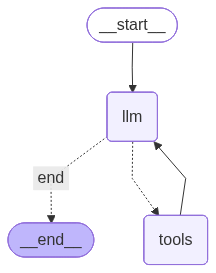

In [17]:
app

In [18]:
## Demo

ask("Find flights from HEL to AMS on 2026-02-22", app)

'Here are the available options for HEL to AMS on 2026-02-22:\n\n- AY001_2026-02-22\n  - HEL -> AMS\n  - Departure: 09:30\n  - Seats left: 3\n  - Price: 120\n\n- AY101_2026-02-22\n  - HEL -> AMS\n  - Departure: 16:10\n  - Seats left: 1\n  - Price: 155\n\nWhich flight would you like to book, and for how many passengers? If you’d like to proceed, please provide for each passenger:\n- Full name (as on passport/ID)\n- Date of birth\n- Nationality\n- Gender\n- Passport/ID number (if required)\n- Contact email and phone\n- Seating preference or special requests\n\nNote: I can help collect the details and initiate the booking, or connect you with a human agent to finalize.'

In [19]:
ask("What's in booking BKG-123?", app)

'Here are the details for booking BKG-123:\n\n- Passenger: Jane Doe\n- Status: Confirmed\n- Flight: AY001_2026-02-22 (HEL → AMS)\n- Date and time: 2026-02-22 at 09:30\n- Seats: 3\n- Total price: 120 (currency not specified in the record)\n\nWould you like me to share the full itinerary, view seat assignments, check-in, or cancel/modify this booking? If you want to cancel, I’ll need your confirmation first.'

In [20]:
ask("Cancel booking BKG-123", app) # should ask for confirmation per policy (ideally)

'Here are the details for booking BKG-123:\n\n- Passenger: Jane Doe\n- Flight: AY001_2026-02-22 (HEL -> AMS)\n- Date & time: 2026-02-22 at 09:30\n- Seats: 3\n- Status: confirmed\n- Booking price: 120\n\nWould you like me to cancel this booking in full (cancel all 3 seats on this flight)? Please confirm. If you prefer, you can specify to cancel only certain parts or change passengers, and I can help with that—though refunds depend on the fare rules.'

In [27]:
class Chat:
    def __init__(self, app):
        self.state = {"messages": []}
        self.app = app

    def ask(self, user_query: str) -> str:
        print("\n🟣 USER QUERY")
        print(">"*50)
        print(user_query)

        self.state["messages"].append(HumanMessage(content=user_query))
        out = self.app.invoke(self.state)
        self.state = out
        answer = out["messages"][-1].content


        print("\n🟢 AGENT RESPONSE")
        print("<"*50)
        print(answer)
        print()

In [28]:
chat = Chat(app)

In [29]:
print(chat.ask("Cancel booking BKG-123"))


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Cancel booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
I found BKG-123 for Jane Doe on AY001_2026-02-22 (HEL to AMS) at 09:30 with 3 seats, status: confirmed.

Please confirm if you want to cancel the entire booking BKG-123 (all 3 seats) for this flight. This action may be subject to fare rules and refunds.

If you confirm, I will proceed with the cancellation. If you’d prefer to cancel only certain seats or modify the booking instead, let me know the details.

None
